<a href="https://colab.research.google.com/github/ansarifaiyaz28/llm-finetune/blob/main/fine_tune_llama_1b_summarization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/ansarifaiyaz28/llm-finetune/blob/main/media/llama-banner.png?raw=1" width="700" height="450" />

In [ ]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [ ]:
pwd

'/content'

In [ ]:
# Uncomment this while running in Colab. Once it runs, enter your HuggingFace token ID.
# This is essential to access the gated Llama model.
from huggingface_hub import notebook_login
notebook_login()

## Llama 3.2 (Model info)

The Llama 3.2 collection of multilingual large language models (LLMs) is a collection of pre-trained and instruction-tuned generative models in 1B and 3B sizes (text in/text out). The Llama 3.2 instruction-tuned text only models are optimized for multilingual dialogue use cases, including agentic retrieval and summarization tasks. They outperform many of the available open source and closed chat models on common industry benchmarks.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# Use model ID if the pre-trained model isn't available locally.
model_id = 'meta-llama/Llama-3.2-1B'
# pretrained_model_location = './tiny-stories/models/meta-llama-3_2-1B'
pretrained_model = AutoModelForCausalLM.from_pretrained(model_id)

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_id)

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

In [ ]:
f'Vocab Size: {tokenizer.vocab_size}'

'Vocab Size: 128000'

In [ ]:
pretrained_model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (ro

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from datasets import load_from_disk

# story_summary_pairs = load_from_disk('./tiny-stories/datasets/tiny-story-summaries-500k')
story_summary_pairs = load_from_disk('/content/drive/MyDrive/Colab Notebooks/datasets/tiny-story-summaries-500k')

In [ ]:
story_summary_pairs

Dataset({
    features: ['story', 'summary'],
    num_rows: 500000
})

In [ ]:
story_summary_pairs['story'][10], story_summary_pairs['summary'][10]

('Tom and Mia went to a pizza place with their mom and dad. They were hungry and excited. They sat at a big table and looked at the menu. The menu had pictures of different pizzas. Tom liked cheese pizza and Mia liked pepperoni pizza. "What do you want to eat?" mom asked. "I want cheese pizza!" Tom said. "I want pepperoni pizza!" Mia said. "Okay, we will order one cheese pizza and one pepperoni pizza," dad said. He gave the menu to the waiter. Soon, the pizzas came. They smelled good and looked yummy. Mom and dad used a big knife to cut the pizzas into slices. They gave Tom and Mia each a slice on a plate. "Be careful, the pizza is hot," mom said. Tom and Mia blew on their pizza to cool it down. Then they took a bite. It was delicious. They smiled and said, "Thank you, mom and dad!" They ate their pizza and drank some juice. They were happy and full. They saw that the pizza place had a big window. Outside, it was dark. The stars and the moon were shining. "Look, it\'s dark outside," To

In [ ]:
def create_prompt_template(batched_dataset):
    return {
        'prompt': [f'{tokenizer.bos_token} {story} \nSummary: {summary} {tokenizer.eos_token}'
        for story, summary in zip(batched_dataset['story'], batched_dataset['summary'])]
    }

In [ ]:
story_summary_pairs_with_prompt = story_summary_pairs.map(create_prompt_template, batched=True)

In [ ]:
story_summary_pairs_with_prompt

Dataset({
    features: ['story', 'summary', 'prompt'],
    num_rows: 500000
})

In [ ]:
story_summary_pairs_with_prompt['story'][10001], story_summary_pairs_with_prompt['summary'][10001], story_summary_pairs_with_prompt['prompt'][10001]

('Once upon a time, there was a little bird. The bird was white and had a pretty song. One day, the bird saw a big pit. The pit was deep and dark. The bird wanted to see what was inside, so it flew down to take a look. As the bird got closer, the pit began to rise up and swallow the bird. The bird tried to fly away, but it was too late. The pit had taken the bird down. The moral of the story is that we should be careful when we see something dangerous. We should not go near it, even if we are curious. It is better to be safe than sorry.',
 'A curious bird flies down to look inside a deep pit and is swallowed by it, teaching a lesson to be careful with dangerous things.',
 '<|begin_of_text|> Once upon a time, there was a little bird. The bird was white and had a pretty song. One day, the bird saw a big pit. The pit was deep and dark. The bird wanted to see what was inside, so it flew down to take a look. As the bird got closer, the pit began to rise up and swallow the bird. The bird tri

In [ ]:
def create_prompt_template(batched_dataset):
    return {
        'tokenized_prompt': [tokenizer.encode(prompt) for prompt in batched_dataset['prompt']]
    }

In [ ]:
# .map() takes a batch of prompts and return tokenized value for each prompt.
# .map can also be done using for loop but .map() function is hastle free
story_summary_pairs_with_prompt_tokenized =  story_summary_pairs_with_prompt.map(
    create_prompt_template, batched=True
)

In [ ]:
story_summary_pairs_with_prompt_tokenized

Dataset({
    features: ['story', 'summary', 'prompt', 'tokenized_prompt'],
    num_rows: 500000
})

In [ ]:
print(story_summary_pairs_with_prompt_tokenized['story'][10])
print(story_summary_pairs_with_prompt_tokenized['summary'][10])
print(story_summary_pairs_with_prompt_tokenized['prompt'][10])
print(story_summary_pairs_with_prompt_tokenized['tokenized_prompt'][10])

Tom and Mia went to a pizza place with their mom and dad. They were hungry and excited. They sat at a big table and looked at the menu. The menu had pictures of different pizzas. Tom liked cheese pizza and Mia liked pepperoni pizza. "What do you want to eat?" mom asked. "I want cheese pizza!" Tom said. "I want pepperoni pizza!" Mia said. "Okay, we will order one cheese pizza and one pepperoni pizza," dad said. He gave the menu to the waiter. Soon, the pizzas came. They smelled good and looked yummy. Mom and dad used a big knife to cut the pizzas into slices. They gave Tom and Mia each a slice on a plate. "Be careful, the pizza is hot," mom said. Tom and Mia blew on their pizza to cool it down. Then they took a bite. It was delicious. They smiled and said, "Thank you, mom and dad!" They ate their pizza and drank some juice. They were happy and full. They saw that the pizza place had a big window. Outside, it was dark. The stars and the moon were shining. "Look, it's dark outside," Tom s

In [ ]:
tokenizer.encode('...')

[128000, 1131]

In [ ]:
tokenizer.pad_token_id = 1131
tokenizer.pad_token

'...'

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class TinyStoryDataset(Dataset):
    def __init__(self, tokenized_list):
        self.data = tokenized_list['tokenized_prompt']

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long, device=device)

In [ ]:
# create an instance of dataset with only the tokenized_prompt with length and index features
tokenized_dataset = TinyStoryDataset(story_summary_pairs_with_prompt_tokenized)

In [ ]:
tokenized_dataset[10][0:14]

tensor([128000, 128000,   8529,    323,  61697,   4024,    311,    264,  23317,
          2035,    449,    872,   3450,    323])

In [ ]:
len(tokenized_dataset)

500000

In [ ]:
from torch.nn.utils.rnn import pad_sequence

def dynamic_collate_fn(batch):
    pad_token_id = tokenizer.pad_token_id

    # 1. Pad the sequences so they all match the longest one in this batch
    padded_input_ids = pad_sequence(batch, batch_first=True, padding_value=pad_token_id)

    # 2. For Causal LM, labels are a direct copy of the input_ids
    # Without cloning, modifying labels could also modify padded_input_ids,
    # because they might refer to the same tensor storage.
    labels = padded_input_ids.clone()

    # 3. Dynamically create the attention mask
    # It creates a tensor of 1s where the token is real, and 0s where it is padding
    attention_masks = (padded_input_ids != pad_token_id).long()

    # 4. Replace padding token ids in labels with -100 to ignore them in loss calculation
    # PyTorch’s cross-entropy loss conventionally ignores target positions whose label is -100.
    labels[labels == pad_token_id] = -100

    # 5. Return the neat dictionary that standard NLP models expect
    return {
        'input_ids': padded_input_ids,
        'attention_mask': attention_masks,
        'labels': labels
    }

In [ ]:
train_dataloader = DataLoader(
    tokenized_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=dynamic_collate_fn
)

In [ ]:
first_batch = next(iter(train_dataloader))
first_batch['input_ids'].shape, first_batch['attention_mask'].shape, first_batch['labels'].shape

(torch.Size([8, 252]), torch.Size([8, 252]), torch.Size([8, 252]))

In [ ]:
print(tokenizer.decode(first_batch['input_ids'].tolist()[0]))
print('\n')
print(tokenizer.decode([label if label != -100 else tokenizer.pad_token_id for label in first_batch['labels'].tolist()[0]]))

<|begin_of_text|><|begin_of_text|> Once upon a time there were two friends, Ben and Bill. Ben was a blue bird and Bill was a brown bear. Ben flew up high each day to find tasty treats and Bill usually walked around looking for food. One day Ben said to Bill, "Let's go swimming in the pond, come on!" "Oh no," Bill said, "It's too deep for me. I can't swim." Ben smiled and said, "Don't worry my honest friend. I'll stay with you and keep you safe." So Ben and Bill went to the pond and Ben held Bill's paw as Bill hopped in. Together they splashed, laughed, and had so much fun. When it got dark, Ben took Bill home and the two friends said goodbye. Bill dried his fur off with a big smile and thanked Ben for being a good friend. Summary: A blue bird and a brown bear become friends and go swimming in a pond. The bird helps the bear who cannot swim and they have fun together. 
Summary: A blue bird and a brown bear become friends and go swimming in a pond. The bird helps the bear who cannot swim

In [ ]:
print(first_batch['attention_mask'].tolist()[0])

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
pretrained_model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (ro

## Model Architecture changes - Implementing LoRA

Low-Rank Adaptation, or LoRA, freezes the pretrained model weights and injects trainable rank decomposition matrices into each layer of the Transformer architecture, greatly reducing the number of trainable parameters for downstream tasks.

<img src="https://github.com/ansarifaiyaz28/llm-finetune/blob/main/media/lora-llama.png?raw=1" width="1000" height="300" />

In [ ]:
import math

class LoRALayer(torch.nn.Module):
    def __init__(self, in_dim, out_dim, rank, alpha):
        super().__init__()
        self.A = torch.nn.Parameter(torch.empty(in_dim, rank, dtype=torch.bfloat16))
        torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
        self.B = torch.nn.Parameter(torch.zeros(rank, out_dim, dtype=torch.bfloat16))
        self.alpha = alpha
        self.rank = rank

    def forward(self, x):
        x = (self.alpha / self.rank) * (x @ self.A @ self.B)
        return x

In [ ]:
class LinearWithLoRA(torch.nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear
        self.lora = LoRALayer(
            linear.in_features, linear.out_features, rank, alpha
        )

    def forward(self, x):
        return self.linear(x) + self.lora(x)

In [ ]:
def replace_linear_with_lora(model, rank, alpha):
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear):
            setattr(model, name, LinearWithLoRA(module, rank, alpha))
        else:
            replace_linear_with_lora(module, rank, alpha)

In [ ]:
# Freeze the model parameters.
total_params = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')

for param in pretrained_model.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)
print(f'Total trainable parameters after freezing the model: {total_params:,}')

Total trainable parameters: 1,235,814,400
Total trainable parameters after freezing the model: 0


In [ ]:
replace_linear_with_lora(pretrained_model, rank=16, alpha=16)

total_params = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)
print(f'Total trainable parameters after applying LoRA: {total_params:,}')

Total trainable parameters after applying LoRA: 13,357,056


In [ ]:
pretrained_model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): LinearWithLoRA(
            (linear): Linear(in_features=2048, out_features=2048, bias=False)
            (lora): LoRALayer()
          )
          (k_proj): LinearWithLoRA(
            (linear): Linear(in_features=2048, out_features=512, bias=False)
            (lora): LoRALayer()
          )
          (v_proj): LinearWithLoRA(
            (linear): Linear(in_features=2048, out_features=512, bias=False)
            (lora): LoRALayer()
          )
          (o_proj): LinearWithLoRA(
            (linear): Linear(in_features=2048, out_features=2048, bias=False)
            (lora): LoRALayer()
          )
        )
        (mlp): LlamaMLP(
          (gate_proj): LinearWithLoRA(
            (linear): Linear(in_features=2048, out_features=8192, bias=False)
            (lora): LoRALayer()


In [ ]:
pretrained_model.to(device)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): LinearWithLoRA(
            (linear): Linear(in_features=2048, out_features=2048, bias=False)
            (lora): LoRALayer()
          )
          (k_proj): LinearWithLoRA(
            (linear): Linear(in_features=2048, out_features=512, bias=False)
            (lora): LoRALayer()
          )
          (v_proj): LinearWithLoRA(
            (linear): Linear(in_features=2048, out_features=512, bias=False)
            (lora): LoRALayer()
          )
          (o_proj): LinearWithLoRA(
            (linear): Linear(in_features=2048, out_features=2048, bias=False)
            (lora): LoRALayer()
          )
        )
        (mlp): LlamaMLP(
          (gate_proj): LinearWithLoRA(
            (linear): Linear(in_features=2048, out_features=8192, bias=False)
            (lora): LoRALayer()


In [ ]:
import torch

def generate_content(prompt):
    encoded_ids = tokenizer.encode(prompt)
    encoded_ids = torch.tensor(encoded_ids, dtype=torch.int64, device=device)

    encoded_ids = encoded_ids.view(1, encoded_ids.shape[-1])

    generated_ids = pretrained_model.generate(
        encoded_ids, max_length=500, pad_token_id=tokenizer.eos_token_id
    )

    print(tokenizer.decode(generated_ids)[0])

In [ ]:
# Checking the initial model performance in un-affected
generate_content('Hey, how are you')

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


<|begin_of_text|>Hey, how are you? I hope you are doing well. Today I am sharing a card that I made using the new stamp set called “Hello Summer” from the new Stampin’ Up! Annual Catalogue.
The card base is stamped with the “Hello Summer” stamp set in Soft Suede ink. I then stamped the “Happy” sentiment in Soft Suede ink and cut it out with the coordinating “Happy” die.
I stamped the “Hello Summer” sentiment in Soft Suede ink and cut it out with the coordinating “Hello Summer” die.
I stamped the “Happy” sentiment in Soft Suede ink and cut it out with the coordinating “Happy” die.
I stamped the “Hello Summer” sentiment in Soft Suede ink and cut it out with the coordinating “Hello Summer” die.
I stamped the “Hello Summer” sentiment in Soft Suede ink and cut it out with the coordinating “Hello Summer” die.
I stamped the “Hello Summer” sentiment in Soft Suede ink and cut it out with the coordinating “Hello Summer” die.
I stamped the “Hello Summer” sentiment in Soft Suede ink and cut it out

In [ ]:
from torch.optim import AdamW
from transformers import get_scheduler

# Standard learning rate for fine-tuning
learning_rate = 5e-5
num_epochs = 1

optimizer = AdamW(pretrained_model.parameters(), lr=learning_rate)

# Calculate total training steps
num_training_steps = num_epochs * len(train_dataloader)

# Set up the learning rate scheduler
lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

In [ ]:
num_epochs
len(train_dataloader)
for batch in train_dataloader:
  print(len(batch))
  break

3


In [ ]:
story_summary_pairs_with_prompt_tokenized['story'][1001]

"Once upon a time, there was a little girl named Lily. She loved to play outside in the park. One day, Lily saw a big swing and she wanted to try it. But she was too scared to swing high. Lily's mom said they had to go home soon, so Lily ran up the stairs to go down the slide one last time. As she was going down the slide, she saw a lady with a basket of apples. The lady told Lily that the apples were delicious and gave her one to try. Lily took a bite of the apple and it was so yummy! She felt happy and brave. So, she ran back to the swing and started to swing higher and higher. She felt like she could touch the sky! From that day on, Lily loved to swing and always remembered the delicious apple that gave her courage. Summary: Lily overcomes her fear of swinging high after trying a delicious apple given to her by a kind lady in the park."

In [ ]:
story_summary_pairs_with_prompt_tokenized['story'][1001]

"Once upon a time, there was a little girl named Lily. She loved to play outside in the park. One day, Lily saw a big swing and she wanted to try it. But she was too scared to swing high. Lily's mom said they had to go home soon, so Lily ran up the stairs to go down the slide one last time. As she was going down the slide, she saw a lady with a basket of apples. The lady told Lily that the apples were delicious and gave her one to try. Lily took a bite of the apple and it was so yummy! She felt happy and brave. So, she ran back to the swing and started to swing higher and higher. She felt like she could touch the sky! From that day on, Lily loved to swing and always remembered the delicious apple that gave her courage. Summary: Lily overcomes her fear of swinging high after trying a delicious apple given to her by a kind lady in the park."

In [ ]:
f'{tokenizer.bos_token} {story_summary_pairs_with_prompt_tokenized['story'][10001]} \nSummary: '

'<|begin_of_text|> Once upon a time, there was a little bird. The bird was white and had a pretty song. One day, the bird saw a big pit. The pit was deep and dark. The bird wanted to see what was inside, so it flew down to take a look. As the bird got closer, the pit began to rise up and swallow the bird. The bird tried to fly away, but it was too late. The pit had taken the bird down. The moral of the story is that we should be careful when we see something dangerous. We should not go near it, even if we are curious. It is better to be safe than sorry. \nSummary: '

In [ ]:
generate_content(f'{tokenizer.bos_token} {story_summary_pairs_with_prompt_tokenized['story'][50001]} \nSummary: ')

<|begin_of_text|><|begin_of_text|> Once upon a time, there was a little girl named Lily. She loved dressing up in her favorite costumes and pretending to be different characters. One day, Lily's mom bought her an original superhero costume. Lily was so excited and couldn't wait to show her friends. Lily went to her friend's house to play. She showed her friends her new superhero costume and they all loved it. But then, one of her friends said that her costume was better. Lily didn't like that and it made her feel sad.  Lily decided to show her friends how fast she could run in her new costume. She ran so fast that she didn't see the big rock in front of her. She tripped and fell, and her costume ripped. Lily started crying and her friends tried to help her, but it was too late.  Lily's mom had to buy her a new costume, but it wasn't the same as the original one. Lily learned that it's not important to have the best costume or be the fastest, but to have fun and be safe. 
Summary:  Lily

In [ ]:
generate_content(f'{tokenizer.bos_token} {story_summary_pairs_with_prompt_tokenized['story'][50001]} \nSummary: ')

<|begin_of_text|><|begin_of_text|> Once upon a time, there was a little girl named Lily. She loved dressing up in her favorite costumes and pretending to be different characters. One day, Lily's mom bought her an original superhero costume. Lily was so excited and couldn't wait to show her friends. Lily went to her friend's house to play. She showed her friends her new superhero costume and they all loved it. But then, one of her friends said that her costume was better. Lily didn't like that and it made her feel sad.  Lily decided to show her friends how fast she could run in her new costume. She ran so fast that she didn't see the big rock in front of her. She tripped and fell, and her costume ripped. Lily started crying and her friends tried to help her, but it was too late.  Lily's mom had to buy her a new costume, but it wasn't the same as the original one. Lily learned that it's not important to have the best costume or be the fastest, but to have fun and be safe. 
Summary:  Lily

In [ ]:
generate_content(f'{tokenizer.bos_token} {story_summary_pairs_with_prompt_tokenized['story'][50001]} \nSummary: ')

<|begin_of_text|><|begin_of_text|> Once upon a time, there was a little girl named Lily. She loved dressing up in her favorite costumes and pretending to be different characters. One day, Lily's mom bought her an original superhero costume. Lily was so excited and couldn't wait to show her friends. Lily went to her friend's house to play. She showed her friends her new superhero costume and they all loved it. But then, one of her friends said that her costume was better. Lily didn't like that and it made her feel sad.  Lily decided to show her friends how fast she could run in her new costume. She ran so fast that she didn't see the big rock in front of her. She tripped and fell, and her costume ripped. Lily started crying and her friends tried to help her, but it was too late.  Lily's mom had to buy her a new costume, but it wasn't the same as the original one. Lily learned that it's not important to have the best costume or be the fastest, but to have fun and be safe. 
Summary:  Lily

In [ ]:
import time
import torch

pretrained_model.train()

warmup_steps = 3
measured_steps = 20
step_times = []

iterator = iter(train_dataloader)

for step in range(warmup_steps + measured_steps):
    batch = next(iterator)
    batch = {
        key: value.to(device, non_blocking=True)
        for key, value in batch.items()
    }

    torch.cuda.synchronize()
    start = time.perf_counter()

    optimizer.zero_grad(set_to_none=True)
    loss = pretrained_model(**batch).loss
    loss.backward()
    optimizer.step()
    lr_scheduler.step()

    torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    if step >= warmup_steps:
        step_times.append(elapsed)

average_step_seconds = sum(step_times) / len(step_times)
total_steps = num_epochs * len(train_dataloader)
estimated_hours = average_step_seconds * total_steps / 3600

print(f"Average step: {average_step_seconds:.3f} seconds")
print(f"Total steps: {total_steps:,}")
print(f"Estimated training time: {estimated_hours:.2f} hours")

Average step: 0.165 seconds
Total steps: 62,500
Estimated training time: 2.87 hours


In [ ]:
from tqdm.auto import tqdm

import os
import torch



progress_bar = tqdm(range(num_training_steps), desc="Training")
pretrained_model.train() # Put model in training mode

losses = []

for epoch in range(num_epochs):
    for batch in train_dataloader:
        # if batch['input_ids'].shape[1] > 511:
        #     continue

        # Move all tensors in the batch to the designated device
        batch = {k: v for k, v in batch.items()}

        # 1. Forward pass
        # print('Forward Pass...')
        outputs = pretrained_model(**batch)
        loss = outputs.loss

        # 2. Backward pass
        # print(f'Back propagate...: {loss}')
        loss.backward()
        losses.append(loss)

        # 3. Update weights and learning rate
        # print('Taking a step back')
        optimizer.step()
        lr_scheduler.step()

        # 4. Clear gradients for the next step
        # print('Clear gradients...')
        optimizer.zero_grad()

        # Update progress bar and print loss
        # print('Updating progress bar...')
        progress_bar.update(1)
        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

        # break


Training:   0%|          | 0/62500 [00:00<?, ?it/s]

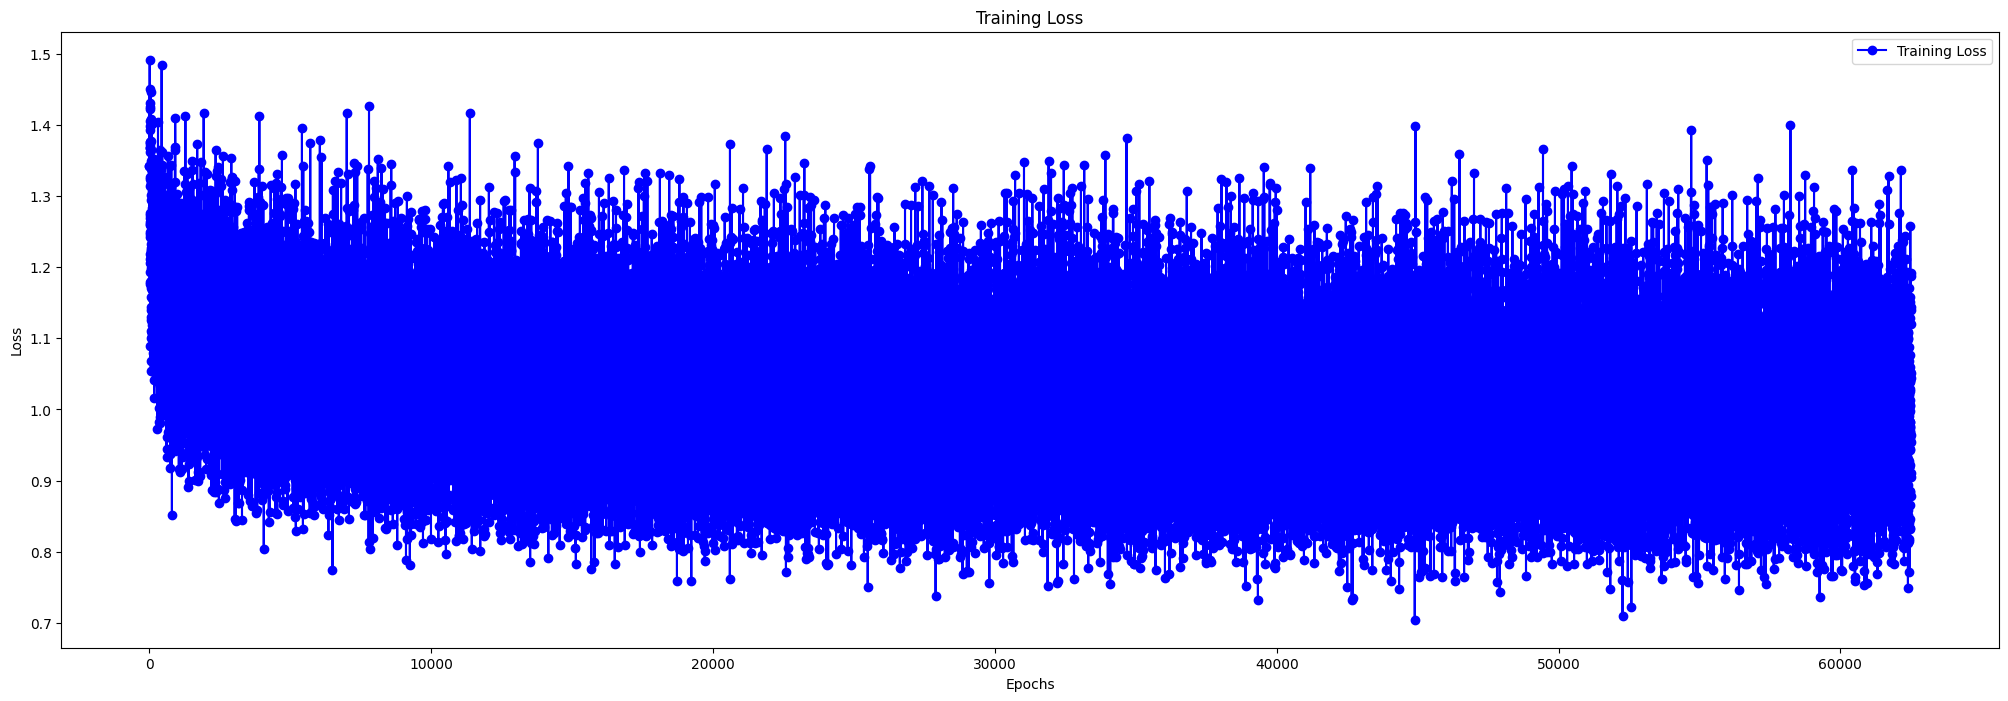

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 8))

# Plotting
plt.plot([(i+1) for i, loss in enumerate(losses)], [loss.item() for loss in losses], 'bo-', label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Generated Loss Curve

![Loss Curve](https://github.com/ansarifaiyaz28/llm-finetune/blob/main/media/llama-finetune-loss-curve.png?raw=1)

In [ ]:
story_summary_pairs_with_prompt_tokenized['story'][1001]

"Once upon a time, there was a little girl named Lily. She loved to play outside in the park. One day, Lily saw a big swing and she wanted to try it. But she was too scared to swing high. Lily's mom said they had to go home soon, so Lily ran up the stairs to go down the slide one last time. As she was going down the slide, she saw a lady with a basket of apples. The lady told Lily that the apples were delicious and gave her one to try. Lily took a bite of the apple and it was so yummy! She felt happy and brave. So, she ran back to the swing and started to swing higher and higher. She felt like she could touch the sky! From that day on, Lily loved to swing and always remembered the delicious apple that gave her courage. Summary: Lily overcomes her fear of swinging high after trying a delicious apple given to her by a kind lady in the park."

In [ ]:
f'{tokenizer.bos_token} {story_summary_pairs_with_prompt_tokenized['story'][10001]} \nSummary: '

'<|begin_of_text|> Once upon a time, there was a little bird. The bird was white and had a pretty song. One day, the bird saw a big pit. The pit was deep and dark. The bird wanted to see what was inside, so it flew down to take a look. As the bird got closer, the pit began to rise up and swallow the bird. The bird tried to fly away, but it was too late. The pit had taken the bird down. The moral of the story is that we should be careful when we see something dangerous. We should not go near it, even if we are curious. It is better to be safe than sorry. \nSummary: '

In [ ]:
generate_content(f'{tokenizer.bos_token} {story_summary_pairs_with_prompt_tokenized['story'][50001]} \nSummary: ')

<|begin_of_text|><|begin_of_text|> Once upon a time, there was a little girl named Lily. She loved dressing up in her favorite costumes and pretending to be different characters. One day, Lily's mom bought her an original superhero costume. Lily was so excited and couldn't wait to show her friends. Lily went to her friend's house to play. She showed her friends her new superhero costume and they all loved it. But then, one of her friends said that her costume was better. Lily didn't like that and it made her feel sad.  Lily decided to show her friends how fast she could run in her new costume. She ran so fast that she didn't see the big rock in front of her. She tripped and fell, and her costume ripped. Lily started crying and her friends tried to help her, but it was too late.  Lily's mom had to buy her a new costume, but it wasn't the same as the original one. Lily learned that it's not important to have the best costume or be the fastest, but to have fun and be safe. 
Summary:  Lily

## Save the custom LoRA adapter

Run this after training. It saves only the trained LoRA matrices, the base-model ID,
the LoRA configuration, and the tokenizer. This is the smallest checkpoint and is
the best choice when you may want to resume training later.

In [ ]:
import os
import torch

LORA_RANK = 16
LORA_ALPHA = 16

# Change this path when not using Google Colab.
adapter_output_dir = "/content/drive/MyDrive/Colab Notebooks/models/llama-3.2-1b-summary-lora"

def save_custom_lora_checkpoint(
    model,
    tokenizer,
    output_dir,
    base_model_id,
    rank,
    alpha,
):
    os.makedirs(output_dir, exist_ok=True)

    # Only save the trainable LoRA A and B matrices.
    lora_state_dict = {
        name: parameter.detach().cpu()
        for name, parameter in model.named_parameters()
        if ".lora." in name
    }

    if not lora_state_dict:
        raise RuntimeError("No LoRA parameters were found in the model.")

    checkpoint = {
        "base_model_id": base_model_id,
        "rank": rank,
        "alpha": alpha,
        "lora_state_dict": lora_state_dict,
    }

    checkpoint_path = os.path.join(output_dir, "custom_lora_adapter.pt")
    torch.save(checkpoint, checkpoint_path)
    tokenizer.save_pretrained(output_dir)

    print(f"Saved {len(lora_state_dict)} LoRA tensors to: {checkpoint_path}")

save_custom_lora_checkpoint(
    model=pretrained_model,
    tokenizer=tokenizer,
    output_dir=adapter_output_dir,
    base_model_id=model_id,
    rank=LORA_RANK,
    alpha=LORA_ALPHA,
)


Saved 226 LoRA tensors to: /content/drive/MyDrive/Colab Notebooks/models/llama-3.2-1b-summary-lora/custom_lora_adapter.pt


## Reload the custom LoRA adapter

The custom LoRA layers must be recreated before loading the saved adapter tensors.
The base model is downloaded or loaded separately.


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
import torch

def load_custom_lora_checkpoint(output_dir, device):
    checkpoint_path = os.path.join(output_dir, "custom_lora_adapter.pt")
    checkpoint = torch.load(checkpoint_path, map_location="cpu")

    loaded_model = AutoModelForCausalLM.from_pretrained(
        checkpoint["base_model_id"]
    )

    # Freeze the original base-model parameters.
    for parameter in loaded_model.parameters():
        parameter.requires_grad = False

    # Recreate exactly the same custom LoRA module structure.
    replace_linear_with_lora(
        loaded_model,
        rank=checkpoint["rank"],
        alpha=checkpoint["alpha"],
    )

    load_result = loaded_model.load_state_dict(
        checkpoint["lora_state_dict"],
        strict=False,
    )

    if load_result.unexpected_keys:
        raise RuntimeError(
            f"Unexpected keys while loading LoRA adapter: {load_result.unexpected_keys}"
        )

    loaded_tokenizer = AutoTokenizer.from_pretrained(output_dir)
    loaded_model.to(device)
    loaded_model.eval()

    print("Custom LoRA adapter loaded successfully.")
    return loaded_model, loaded_tokenizer

# Example:
# pretrained_model, tokenizer = load_custom_lora_checkpoint(
#     adapter_output_dir,
#     device,
# )


## Optional: merge LoRA and save a standalone Hugging Face model

Run this only after saving the adapter checkpoint above. The function permanently
merges the LoRA update into the base linear weights and removes the custom wrapper.
The resulting directory can be loaded normally with `from_pretrained()`.


In [ ]:
import os
import torch

merged_output_dir = "/content/drive/MyDrive/Colab Notebooks/models/llama-3.2-1b-summary-merged"

def merge_custom_lora_layers_(module):
    """Merge every LinearWithLoRA child into its original Linear layer in place."""
    for name, child in list(module.named_children()):
        if isinstance(child, LinearWithLoRA):
            with torch.no_grad():
                # Custom LoRA forward:
                # x @ A @ B, while nn.Linear uses x @ weight.T.
                delta_weight = (
                    (child.lora.alpha / child.lora.rank)
                    * (child.lora.A @ child.lora.B).T
                )
                child.linear.weight.add_(
                    delta_weight.to(
                        device=child.linear.weight.device,
                        dtype=child.linear.weight.dtype,
                    )
                )

            setattr(module, name, child.linear)
        else:
            merge_custom_lora_layers_(child)

os.makedirs(merged_output_dir, exist_ok=True)

# This changes pretrained_model in place, so save the adapter first.
merge_custom_lora_layers_(pretrained_model)
pretrained_model.eval()

pretrained_model.save_pretrained(
    merged_output_dir,
    safe_serialization=True,
    max_shard_size="2GB",
)
tokenizer.save_pretrained(merged_output_dir)

print(f"Merged standalone model saved to: {merged_output_dir}")


Writing model shards:   0%|          | 0/2 [00:00<?, ?it/s]

Merged standalone model saved to: /content/drive/MyDrive/Colab Notebooks/models/llama-3.2-1b-summary-merged
